# Laboratorio 7


In [1]:
import sys
import subprocess
import pkgutil

if pkgutil.find_loader("pyreadr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pyreadr"])

In [2]:
import os
import glob
import json
import time
import tracemalloc
import warnings
import joblib
import numpy as np
import pandas as pd
import pyreadr
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [3]:
warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.20
OUTPUT_DIR = "outputs"
MODEL_DIR = "models"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

In [4]:
def buscar_archivo_rdata():
    candidatos = []
    patrones = [
        os.path.join("data", "*.RData"),
        "*.RData",
        os.path.join("/mnt/data", "*.RData")
    ]
    for patron in patrones:
        candidatos.extend(glob.glob(patron))
    candidatos = sorted(set(candidatos))
    if not candidatos:
        raise FileNotFoundError("No se encontró ningún archivo .RData")
    return candidatos[0]

def limpiar_porcentaje(serie):
    return pd.to_numeric(
        serie.astype(str)
            .str.replace("%", "", regex=False)
            .replace(["", "nan", "None"], np.nan),
        errors="coerce"
    )

def calcular_metricas(y_real, y_pred, y_proba):
    tn, fp, fn, tp = confusion_matrix(y_real, y_pred).ravel()
    sensibilidad = recall_score(y_real, y_pred, zero_division=0)
    especificidad = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    return pd.DataFrame(
        {
            "accuracy": [accuracy_score(y_real, y_pred)],
            "precision": [precision_score(y_real, y_pred, zero_division=0)],
            "recall": [sensibilidad],
            "specificity": [especificidad],
            "f1": [f1_score(y_real, y_pred, zero_division=0)],
            "roc_auc": [roc_auc_score(y_real, y_proba)],
            "tn": [tn],
            "fp": [fp],
            "fn": [fn],
            "tp": [tp]
        }
    )

## Carga de datos

In [5]:
ruta_rdata = buscar_archivo_rdata()
objeto_r = pyreadr.read_r(ruta_rdata)
nombre_objeto = list(objeto_r.keys())[0]
df = objeto_r[nombre_objeto].copy()

print("Archivo usado:", ruta_rdata)
print("Objeto cargado:", nombre_objeto)
print("Dimensiones originales:", df.shape)
display(df.head())

Archivo usado: data\listings.RData
Objeto cargado: listings
Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


## Variable respuesta

In [6]:
df["price_num"] = pd.to_numeric(
    df["price"].astype(str)
      .str.replace("$", "", regex=False)
      .str.replace(",", "", regex=False)
      .replace("", np.nan),
    errors="coerce"
)

df = df.dropna(subset=["price_num"]).copy()

df["categoria_precio"] = pd.qcut(
    df["price_num"],
    q=3,
    labels=["barata", "media", "cara"]
)

df["precio_barata"] = (df["categoria_precio"] == "barata").astype(int)
df["precio_media"] = (df["categoria_precio"] == "media").astype(int)
df["precio_cara"] = (df["categoria_precio"] == "cara").astype(int)
df["es_cara"] = df["precio_cara"]

resumen_categorias = (
    df["categoria_precio"]
      .value_counts()
      .rename_axis("categoria")
      .reset_index(name="frecuencia")
)

display(resumen_categorias)
resumen_categorias.to_csv(os.path.join(OUTPUT_DIR, "resumen_categorias_precio.csv"), index=False)

,categoria,frecuencia
0,barata,25689
1,cara,25404
2,media,25153


## Variables del modelo

In [7]:
columnas_modelo = [
    "city",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "property_type",
    "room_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "estimated_occupancy_l365d",
    "review_scores_rating",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "instant_bookable",
    "reviews_per_month"
]

for col in ["host_response_rate", "host_acceptance_rate"]:
    df[col] = limpiar_porcentaje(df[col])

for col in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "instant_bookable"]:
    df[col] = df[col].replace({"t": "Sí", "f": "No", "": "No"})

X = df[columnas_modelo].copy()
y = df["es_cara"].copy()

tipos_columnas = pd.DataFrame(
    {
        "columna": X.columns,
        "tipo": X.dtypes.astype(str).values,
        "nulos": X.isna().sum().values
    }
)

display(tipos_columnas)
tipos_columnas.to_csv(os.path.join(OUTPUT_DIR, "tipos_y_nulos_modelo.csv"), index=False)

,columna,tipo,nulos
0,city,object,0
1,host_response_rate,float64,5376
2,host_acceptance_rate,float64,4301
3,host_is_superhost,object,0
4,host_has_profile_pic,object,0
5,host_identity_verified,object,0
6,property_type,object,0
7,room_type,object,0
8,accommodates,int32,0
9,bathrooms,float64,14


## Conjuntos de entrenamiento y prueba

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y
)

indices_split = pd.concat(
    [
        pd.DataFrame({"indice_original": X_train.index, "conjunto": "train"}),
        pd.DataFrame({"indice_original": X_test.index, "conjunto": "test"})
    ],
    ignore_index=True
)

indices_split.to_csv(os.path.join(OUTPUT_DIR, "indices_train_test_precio.csv"), index=False)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Prueba:", X_test.shape, y_test.shape)
display(indices_split.head())

Entrenamiento: (60996, 31) (60996,)
Prueba: (15250, 31) (15250,)


,indice_original,conjunto
0,20317,train
1,23451,train
2,36342,train
3,782,train
4,2255,train


## Preprocesamiento

In [9]:
columnas_categoricas = X_train.select_dtypes(include="object").columns.tolist()
columnas_numericas = [col for col in X_train.columns if col not in columnas_categoricas]

preprocesador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ]
            ),
            columnas_numericas
        ),
        (
            "categoricas",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="infrequent_if_exist",
                            min_frequency=0.01
                        )
                    )
                ]
            ),
            columnas_categoricas
        )
    ]
)

print("Variables numéricas:", len(columnas_numericas))
print("Variables categóricas:", len(columnas_categoricas))
display(pd.DataFrame({"numericas": pd.Series(columnas_numericas)}))
display(pd.DataFrame({"categoricas": pd.Series(columnas_categoricas)}))

Variables numéricas: 22
Variables categóricas: 9


,numericas
0,host_response_rate
1,host_acceptance_rate
2,accommodates
3,bathrooms
4,minimum_nights
5,maximum_nights
6,availability_30
7,availability_60
8,availability_90
9,availability_365


,categoricas
0,city
1,host_is_superhost
2,host_has_profile_pic
3,host_identity_verified
4,property_type
5,room_type
6,bedrooms
7,beds
8,instant_bookable


## Tuneo del modelo

In [10]:
pipeline_logistico = Pipeline(
    steps=[
        ("preprocesador", preprocesador),
        (
            "modelo",
            LogisticRegression(
                solver="saga",
                max_iter=2000,
                random_state=SEED,
                n_jobs=-1
            )
        )
    ]
)

param_grid = {
    "modelo__penalty": ["l1", "l2"],
    "modelo__C": [0.1, 1, 10]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=SEED
)

grid_search = GridSearchCV(
    estimator=pipeline_logistico,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1
)

inicio_tuneo = time.perf_counter()
grid_search.fit(X_train, y_train)
fin_tuneo = time.perf_counter()

resultados_cv = pd.DataFrame(grid_search.cv_results_).sort_values(
    by="rank_test_score"
)

columnas_cv = [
    "params",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

display(resultados_cv[columnas_cv].reset_index(drop=True))
resultados_cv.to_csv(os.path.join(OUTPUT_DIR, "resultados_cv_logistica_cara.csv"), index=False)

mejores_parametros = {
    "best_params": grid_search.best_params_,
    "best_score_f1_cv": float(grid_search.best_score_),
    "tiempo_tuneo_segundos": fin_tuneo - inicio_tuneo
}

with open(os.path.join(OUTPUT_DIR, "mejores_parametros_logistica_cara.json"), "w", encoding="utf-8") as f:
    json.dump(mejores_parametros, f, indent=4, ensure_ascii=False)

mejor_modelo = grid_search.best_estimator_
print(mejores_parametros)

Fitting 3 folds for each of 6 candidates, totalling 18 fits


,params,mean_test_score,std_test_score,rank_test_score
0,"{'modelo__C': 1, 'modelo__penalty': 'l2'}",0.703508,0.002588,1
1,"{'modelo__C': 10, 'modelo__penalty': 'l2'}",0.703496,0.002832,2
2,"{'modelo__C': 10, 'modelo__penalty': 'l1'}",0.703410,0.002834,3
3,"{'modelo__C': 1, 'modelo__penalty': 'l1'}",0.703195,0.002755,4
4,"{'modelo__C': 0.1, 'modelo__penalty': 'l2'}",0.701993,0.002426,5
5,"{'modelo__C': 0.1, 'modelo__penalty': 'l1'}",0.701987,0.002122,6


{'best_params': {'modelo__C': 1, 'modelo__penalty': 'l2'}, 'best_score_f1_cv': 0.7035080659205311, 'tiempo_tuneo_segundos': 98.14359920000425}


## Mejor modelo

In [11]:
tracemalloc.start()
inicio_fit = time.perf_counter()
mejor_modelo.fit(X_train, y_train)
fin_fit = time.perf_counter()
memoria_actual_fit, memoria_pico_fit = tracemalloc.get_traced_memory()
tracemalloc.stop()

joblib.dump(mejor_modelo, os.path.join(MODEL_DIR, "modelo_logistica_cara_tuneado.joblib"))

y_pred_train = mejor_modelo.predict(X_train)
y_pred_test = mejor_modelo.predict(X_test)

y_proba_train = mejor_modelo.predict_proba(X_train)[:, 1]
y_proba_test = mejor_modelo.predict_proba(X_test)[:, 1]

print("Tiempo de ajuste:", fin_fit - inicio_fit)
print("Memoria pico en ajuste (MB):", memoria_pico_fit / (1024 ** 2))

Tiempo de ajuste: 27.174500700028148
Memoria pico en ajuste (MB): 70.77955722808838


## Matrices de confusión

,Pred 0,Pred 1
Real 0,36429,4244
Real 1,6950,13373


,Pred 0,Pred 1
Real 0,9118,1051
Real 1,1707,3374


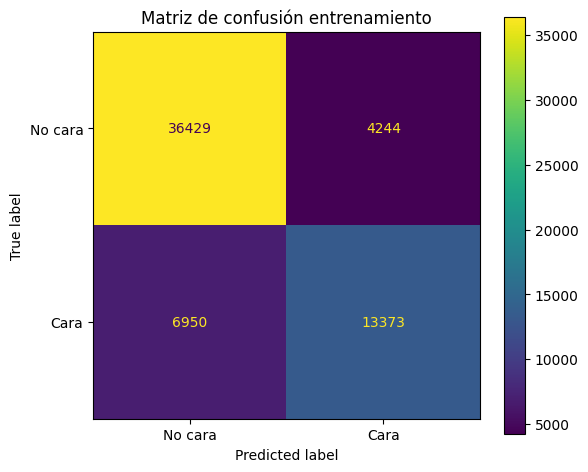

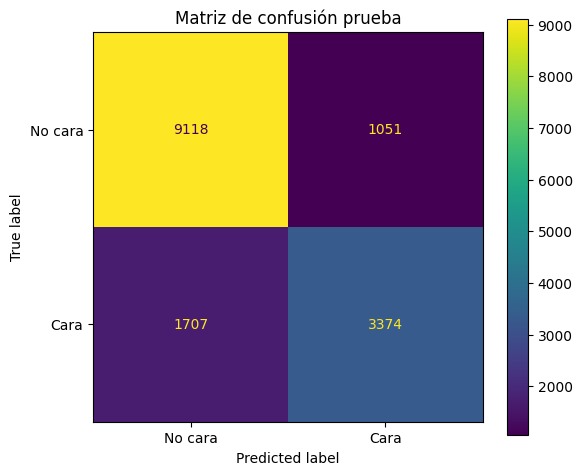

In [12]:
matriz_train = confusion_matrix(y_train, y_pred_train)
matriz_test = confusion_matrix(y_test, y_pred_test)

tabla_matriz_train = pd.DataFrame(
    matriz_train,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

tabla_matriz_test = pd.DataFrame(
    matriz_test,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

display(tabla_matriz_train)
display(tabla_matriz_test)

tabla_matriz_train.to_csv(os.path.join(OUTPUT_DIR, "matriz_confusion_train_05.csv"))
tabla_matriz_test.to_csv(os.path.join(OUTPUT_DIR, "matriz_confusion_test_05.csv"))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz_train, display_labels=["No cara", "Cara"]).plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión entrenamiento")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_train_05.png"), dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz_test, display_labels=["No cara", "Cara"]).plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión prueba")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_test_05.png"), dpi=200, bbox_inches="tight")
plt.show()

## Métricas

In [13]:
metricas_train = calcular_metricas(y_train, y_pred_train, y_proba_train)
metricas_test = calcular_metricas(y_test, y_pred_test, y_proba_test)

metricas_train.insert(0, "conjunto", "train")
metricas_test.insert(0, "conjunto", "test")

metricas_modelo = pd.concat([metricas_train, metricas_test], ignore_index=True)

display(metricas_modelo)

metricas_train.to_csv(os.path.join(OUTPUT_DIR, "metricas_train_logistica_cara.csv"), index=False)
metricas_test.to_csv(os.path.join(OUTPUT_DIR, "metricas_test_logistica_cara.csv"), index=False)
metricas_modelo.to_csv(os.path.join(OUTPUT_DIR, "metricas_logistica_cara.csv"), index=False)

,conjunto,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,train,0.816480,0.759096,0.658023,0.895656,0.704955,0.880933,36429,4244,6950,13373
1,test,0.819148,0.762486,0.664043,0.896647,0.709867,0.884654,9118,1051,1707,3374


## Perfil de tiempo y memoria

In [14]:
tracemalloc.start()
inicio_predict = time.perf_counter()
_ = mejor_modelo.predict(X_test)
_ = mejor_modelo.predict_proba(X_test)
fin_predict = time.perf_counter()
memoria_actual_predict, memoria_pico_predict = tracemalloc.get_traced_memory()
tracemalloc.stop()

perfil = pd.DataFrame(
    {
        "etapa": ["tuneo", "fit", "predict_test"],
        "tiempo_segundos": [
            fin_tuneo - inicio_tuneo,
            fin_fit - inicio_fit,
            fin_predict - inicio_predict
        ],
        "memoria_pico_mb": [
            np.nan,
            memoria_pico_fit / (1024 ** 2),
            memoria_pico_predict / (1024 ** 2)
        ]
    }
)

display(perfil)
perfil.to_csv(os.path.join(OUTPUT_DIR, "perfil_logistica_cara.csv"), index=False)

,etapa,tiempo_segundos,memoria_pico_mb
0,tuneo,98.143599,NaN
1,fit,27.174501,70.779557
2,predict_test,0.284492,17.793786


## Inciso 9

### Ajuste del umbral de decisión con índice de Youden

,umbral_05,umbral_optimo_youden,youden_j_max,sensibilidad_umbral_optimo,especificidad_umbral_optimo
0,0.5,0.315475,0.603864,0.813029,0.790835


,escenario,conjunto,umbral,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,umbral_0.50,train,0.500000,0.816480,0.759096,0.658023,0.895656,0.704955,0.880933,36429,4244,6950,13373
1,umbral_0.50,test,0.500000,0.819148,0.762486,0.664043,0.896647,0.709867,0.884654,9118,1051,1707,3374
2,umbral_youden,train,0.315475,0.795069,0.656454,0.807558,0.788828,0.724208,0.880933,32084,8589,3911,16412
3,umbral_youden,test,0.315475,0.798230,0.660115,0.813029,0.790835,0.728636,0.884654,8042,2127,950,4131


,Pred 0,Pred 1
Real 0,32084,8589
Real 1,3911,16412


,Pred 0,Pred 1
Real 0,8042,2127
Real 1,950,4131


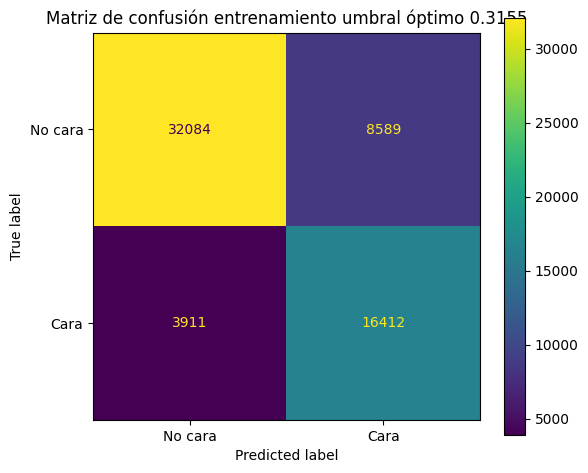

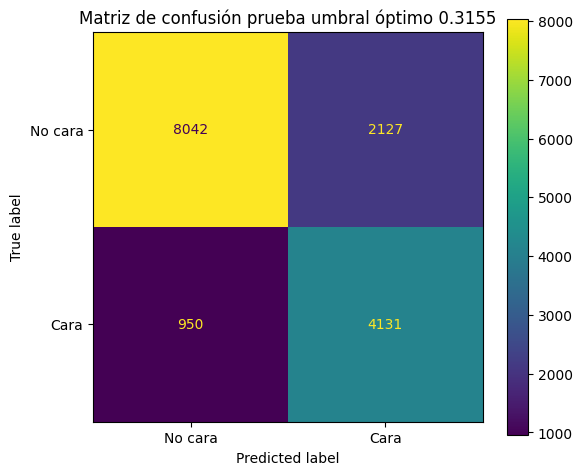

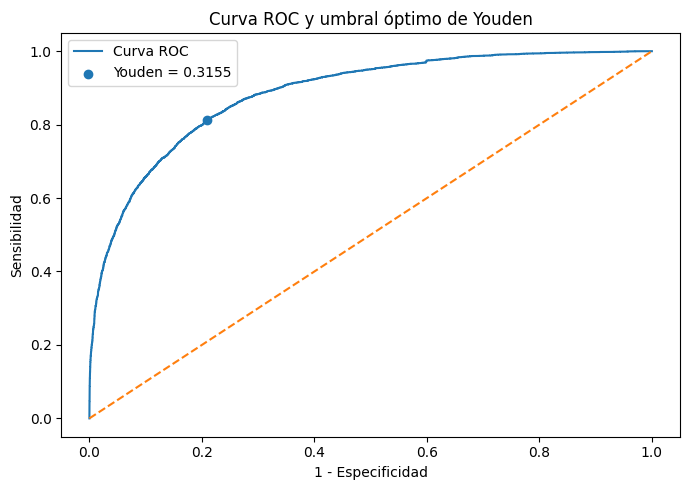

In [15]:
from sklearn.metrics import roc_curve

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)
mascara_umbral = np.isfinite(thresholds_test)
fpr_validos = fpr_test[mascara_umbral]
tpr_validos = tpr_test[mascara_umbral]
thresholds_validos = thresholds_test[mascara_umbral]
youden_j = tpr_validos - fpr_validos
indice_youden = int(np.argmax(youden_j))
umbral_optimo = float(thresholds_validos[indice_youden])

y_pred_train_youden = (y_proba_train >= umbral_optimo).astype(int)
y_pred_test_youden = (y_proba_test >= umbral_optimo).astype(int)

resumen_umbral_youden = pd.DataFrame(
    {
        "umbral_05": [0.50],
        "umbral_optimo_youden": [umbral_optimo],
        "youden_j_max": [float(youden_j[indice_youden])],
        "sensibilidad_umbral_optimo": [float(tpr_validos[indice_youden])],
        "especificidad_umbral_optimo": [float(1 - fpr_validos[indice_youden])]
    }
)

display(resumen_umbral_youden)
resumen_umbral_youden.to_csv(os.path.join(OUTPUT_DIR, "resumen_umbral_youden_logistica_cara.csv"), index=False)

metricas_train_05 = calcular_metricas(y_train, y_pred_train, y_proba_train)
metricas_train_05.insert(0, "escenario", "umbral_0.50")
metricas_train_05.insert(1, "conjunto", "train")
metricas_train_05.insert(2, "umbral", 0.50)

metricas_test_05 = calcular_metricas(y_test, y_pred_test, y_proba_test)
metricas_test_05.insert(0, "escenario", "umbral_0.50")
metricas_test_05.insert(1, "conjunto", "test")
metricas_test_05.insert(2, "umbral", 0.50)

metricas_train_youden = calcular_metricas(y_train, y_pred_train_youden, y_proba_train)
metricas_train_youden.insert(0, "escenario", "umbral_youden")
metricas_train_youden.insert(1, "conjunto", "train")
metricas_train_youden.insert(2, "umbral", umbral_optimo)

metricas_test_youden = calcular_metricas(y_test, y_pred_test_youden, y_proba_test)
metricas_test_youden.insert(0, "escenario", "umbral_youden")
metricas_test_youden.insert(1, "conjunto", "test")
metricas_test_youden.insert(2, "umbral", umbral_optimo)

comparacion_umbrales = pd.concat(
    [
        metricas_train_05,
        metricas_test_05,
        metricas_train_youden,
        metricas_test_youden
    ],
    ignore_index=True
)

display(comparacion_umbrales)
comparacion_umbrales.to_csv(os.path.join(OUTPUT_DIR, "comparacion_umbrales_logistica_cara.csv"), index=False)

matriz_train_youden = confusion_matrix(y_train, y_pred_train_youden)
matriz_test_youden = confusion_matrix(y_test, y_pred_test_youden)

tabla_matriz_train_youden = pd.DataFrame(
    matriz_train_youden,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

tabla_matriz_test_youden = pd.DataFrame(
    matriz_test_youden,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

display(tabla_matriz_train_youden)
display(tabla_matriz_test_youden)

tabla_matriz_train_youden.to_csv(os.path.join(OUTPUT_DIR, "matriz_confusion_train_youden.csv"))
tabla_matriz_test_youden.to_csv(os.path.join(OUTPUT_DIR, "matriz_confusion_test_youden.csv"))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz_train_youden, display_labels=["No cara", "Cara"]).plot(ax=ax, values_format="d")
ax.set_title(f"Matriz de confusión entrenamiento umbral óptimo {umbral_optimo:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_train_youden.png"), dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz_test_youden, display_labels=["No cara", "Cara"]).plot(ax=ax, values_format="d")
ax.set_title(f"Matriz de confusión prueba umbral óptimo {umbral_optimo:.4f}")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "matriz_confusion_test_youden.png"), dpi=200, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_test, tpr_test, label="Curva ROC")
ax.scatter(
    fpr_validos[indice_youden],
    tpr_validos[indice_youden],
    label=f"Youden = {umbral_optimo:.4f}"
)
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("1 - Especificidad")
ax.set_ylabel("Sensibilidad")
ax.set_title("Curva ROC y umbral óptimo de Youden")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "curva_roc_youden_logistica_cara.png"), dpi=200, bbox_inches="tight")
plt.show()

## Inciso 10

### Comparación de modelos y selección del mejor

In [16]:
from sklearn.base import clone
from sklearn.model_selection import ParameterGrid


def calcular_log_likelihood(y_real, y_proba):
    y_real = np.asarray(y_real)
    y_proba = np.clip(np.asarray(y_proba), 1e-12, 1 - 1e-12)
    return float(np.sum(y_real * np.log(y_proba) + (1 - y_real) * np.log(1 - y_proba)))


registros_modelos = []

for params in ParameterGrid(param_grid):
    modelo_actual = clone(pipeline_logistico)
    modelo_actual.set_params(**params)

    tracemalloc.start()
    inicio_actual = time.perf_counter()
    modelo_actual.fit(X_train, y_train)
    fin_actual = time.perf_counter()
    _, memoria_pico_actual = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    proba_train_actual = modelo_actual.predict_proba(X_train)[:, 1]
    proba_test_actual = modelo_actual.predict_proba(X_test)[:, 1]
    pred_train_actual = (proba_train_actual >= 0.50).astype(int)
    pred_test_actual = (proba_test_actual >= 0.50).astype(int)

    metricas_train_actual = calcular_metricas(y_train, pred_train_actual, proba_train_actual).iloc[0]
    metricas_test_actual = calcular_metricas(y_test, pred_test_actual, proba_test_actual).iloc[0]

    coeficientes_actuales = modelo_actual.named_steps["modelo"].coef_.ravel()
    numero_parametros = int(np.count_nonzero(np.abs(coeficientes_actuales) > 1e-10) + 1)
    log_likelihood_train = calcular_log_likelihood(y_train, proba_train_actual)
    aic_actual = float(2 * numero_parametros - 2 * log_likelihood_train)
    bic_actual = float(np.log(len(y_train)) * numero_parametros - 2 * log_likelihood_train)

    registros_modelos.append(
        {
            "modelo": f"penalty={params['modelo__penalty']}_C={params['modelo__C']}_umbral=0.50",
            "penalty": params["modelo__penalty"],
            "C": params["modelo__C"],
            "umbral": 0.50,
            "accuracy_train": float(metricas_train_actual["accuracy"]),
            "precision_train": float(metricas_train_actual["precision"]),
            "recall_train": float(metricas_train_actual["recall"]),
            "specificity_train": float(metricas_train_actual["specificity"]),
            "f1_train": float(metricas_train_actual["f1"]),
            "roc_auc_train": float(metricas_train_actual["roc_auc"]),
            "accuracy_test": float(metricas_test_actual["accuracy"]),
            "precision_test": float(metricas_test_actual["precision"]),
            "recall_test": float(metricas_test_actual["recall"]),
            "specificity_test": float(metricas_test_actual["specificity"]),
            "f1_test": float(metricas_test_actual["f1"]),
            "roc_auc_test": float(metricas_test_actual["roc_auc"]),
            "tn_test": int(metricas_test_actual["tn"]),
            "fp_test": int(metricas_test_actual["fp"]),
            "fn_test": int(metricas_test_actual["fn"]),
            "tp_test": int(metricas_test_actual["tp"]),
            "tiempo_fit_segundos": float(fin_actual - inicio_actual),
            "memoria_pico_fit_mb": float(memoria_pico_actual / (1024 ** 2)),
            "numero_parametros": numero_parametros,
            "log_likelihood_train": log_likelihood_train,
            "aic": aic_actual,
            "bic": bic_actual
        }
    )

coeficientes_mejor = mejor_modelo.named_steps["modelo"].coef_.ravel()
numero_parametros_mejor = int(np.count_nonzero(np.abs(coeficientes_mejor) > 1e-10) + 1)
log_likelihood_mejor = calcular_log_likelihood(y_train, y_proba_train)
aic_mejor = float(2 * numero_parametros_mejor - 2 * log_likelihood_mejor)
bic_mejor = float(np.log(len(y_train)) * numero_parametros_mejor - 2 * log_likelihood_mejor)
metricas_train_mejor_youden = calcular_metricas(y_train, y_pred_train_youden, y_proba_train).iloc[0]
metricas_test_mejor_youden = calcular_metricas(y_test, y_pred_test_youden, y_proba_test).iloc[0]

registros_modelos.append(
    {
        "modelo": f"penalty={grid_search.best_params_['modelo__penalty']}_C={grid_search.best_params_['modelo__C']}_umbral=youden",
        "penalty": grid_search.best_params_["modelo__penalty"],
        "C": grid_search.best_params_["modelo__C"],
        "umbral": umbral_optimo,
        "accuracy_train": float(metricas_train_mejor_youden["accuracy"]),
        "precision_train": float(metricas_train_mejor_youden["precision"]),
        "recall_train": float(metricas_train_mejor_youden["recall"]),
        "specificity_train": float(metricas_train_mejor_youden["specificity"]),
        "f1_train": float(metricas_train_mejor_youden["f1"]),
        "roc_auc_train": float(metricas_train_mejor_youden["roc_auc"]),
        "accuracy_test": float(metricas_test_mejor_youden["accuracy"]),
        "precision_test": float(metricas_test_mejor_youden["precision"]),
        "recall_test": float(metricas_test_mejor_youden["recall"]),
        "specificity_test": float(metricas_test_mejor_youden["specificity"]),
        "f1_test": float(metricas_test_mejor_youden["f1"]),
        "roc_auc_test": float(metricas_test_mejor_youden["roc_auc"]),
        "tn_test": int(metricas_test_mejor_youden["tn"]),
        "fp_test": int(metricas_test_mejor_youden["fp"]),
        "fn_test": int(metricas_test_mejor_youden["fn"]),
        "tp_test": int(metricas_test_mejor_youden["tp"]),
        "tiempo_fit_segundos": float(fin_fit - inicio_fit),
        "memoria_pico_fit_mb": float(memoria_pico_fit / (1024 ** 2)),
        "numero_parametros": numero_parametros_mejor,
        "log_likelihood_train": log_likelihood_mejor,
        "aic": aic_mejor,
        "bic": bic_mejor
    }
)

comparacion_modelos = pd.DataFrame(registros_modelos)
comparacion_modelos["rank_f1"] = comparacion_modelos["f1_test"].rank(ascending=False, method="min")
comparacion_modelos["rank_roc_auc"] = comparacion_modelos["roc_auc_test"].rank(ascending=False, method="min")
comparacion_modelos["rank_bic"] = comparacion_modelos["bic"].rank(ascending=True, method="min")
comparacion_modelos["rank_tiempo"] = comparacion_modelos["tiempo_fit_segundos"].rank(ascending=True, method="min")
comparacion_modelos["rank_memoria"] = comparacion_modelos["memoria_pico_fit_mb"].rank(ascending=True, method="min")
comparacion_modelos["puntaje_global"] = (
    comparacion_modelos["rank_f1"]
    + comparacion_modelos["rank_roc_auc"]
    + comparacion_modelos["rank_bic"]
    + comparacion_modelos["rank_tiempo"]
    + comparacion_modelos["rank_memoria"]
)
comparacion_modelos = comparacion_modelos.sort_values(
    by=["puntaje_global", "f1_test", "roc_auc_test", "bic"],
    ascending=[True, False, False, True]
).reset_index(drop=True)
comparacion_modelos.insert(0, "ranking_final", np.arange(1, len(comparacion_modelos) + 1))

columnas_resumen = [
    "ranking_final",
    "modelo",
    "umbral",
    "accuracy_test",
    "precision_test",
    "recall_test",
    "specificity_test",
    "f1_test",
    "roc_auc_test",
    "aic",
    "bic",
    "tiempo_fit_segundos",
    "memoria_pico_fit_mb",
    "puntaje_global"
]

display(comparacion_modelos[columnas_resumen])
comparacion_modelos.to_csv(os.path.join(OUTPUT_DIR, "comparacion_modelos_logistica_cara.csv"), index=False)
comparacion_modelos[columnas_resumen].to_csv(os.path.join(OUTPUT_DIR, "comparacion_modelos_logistica_cara_resumen.csv"), index=False)

mejor_modelo_final = comparacion_modelos.head(1)
display(mejor_modelo_final[columnas_resumen])
mejor_modelo_final.to_csv(os.path.join(OUTPUT_DIR, "mejor_modelo_logistica_cara.csv"), index=False)

,ranking_final,modelo,umbral,accuracy_test,precision_test,recall_test,specificity_test,f1_test,roc_auc_test,aic,bic,tiempo_fit_segundos,memoria_pico_fit_mb,puntaje_global
0,1,penalty=l2_C=10_umbral=0.50,0.500000,0.819148,0.762249,0.664436,0.896450,0.709989,0.884683,49150.613787,49781.913237,30.896725,70.769644,11.0
1,2,penalty=l1_C=10_umbral=0.50,0.500000,0.819148,0.762249,0.664436,0.896450,0.709989,0.884682,49150.616686,49781.916136,38.927049,70.771090,18.0
2,3,penalty=l1_C=1_umbral=0.50,0.500000,0.819148,0.762486,0.664043,0.896647,0.709867,0.884660,49145.009531,49749.253290,41.458032,70.769975,18.0
3,4,penalty=l2_C=1_umbral=youden,0.315475,0.798230,0.660115,0.813029,0.790835,0.728636,0.884654,49150.927712,49782.227162,27.174501,70.779557,19.0
4,5,penalty=l2_C=1_umbral=0.50,0.500000,0.819148,0.762486,0.664043,0.896647,0.709867,0.884654,49150.927712,49782.227162,30.167089,70.770456,19.0
5,6,penalty=l2_C=0.1_umbral=0.50,0.500000,0.818623,0.762531,0.661681,0.897040,0.708535,0.884408,49168.419617,49799.719067,22.180999,70.770933,25.0
6,7,penalty=l1_C=0.1_umbral=0.50,0.500000,0.819082,0.762551,0.663649,0.896745,0.709671,0.884386,49146.291967,49633.294399,41.209497,70.777401,26.0


,ranking_final,modelo,umbral,accuracy_test,precision_test,recall_test,specificity_test,f1_test,roc_auc_test,aic,bic,tiempo_fit_segundos,memoria_pico_fit_mb,puntaje_global
0,1,penalty=l2_C=10_umbral=0.50,0.5,0.819148,0.762249,0.664436,0.89645,0.709989,0.884683,49150.613787,49781.913237,30.896725,70.769644,11.0


## Archivos generados

In [17]:
archivos_generados = []
for carpeta in [OUTPUT_DIR, MODEL_DIR]:
    for archivo in sorted(os.listdir(carpeta)):
        archivos_generados.append({"carpeta": carpeta, "archivo": archivo})

archivos_generados = pd.DataFrame(archivos_generados)
display(archivos_generados)

,carpeta,archivo
0,outputs,comparacion_modelos_logistica_cara.csv
1,outputs,comparacion_modelos_logistica_cara_resumen.csv
2,outputs,comparacion_umbrales_logistica_cara.csv
3,outputs,curva_roc_youden_logistica_cara.png
4,outputs,indices_train_test_precio.csv
5,outputs,matriz_confusion_test_05.csv
6,outputs,matriz_confusion_test_05.png
7,outputs,matriz_confusion_test_youden.csv
8,outputs,matriz_confusion_test_youden.png
9,outputs,matriz_confusion_train_05.csv
